In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
import seaborn as sns

In [8]:
def set_fig_theme():
    sns.set_theme(context="paper", style="whitegrid", font="serif")
    plt.rcParams.update(
        {
            # Font
            "font.family": "serif",
            "font.size": 12,  # IEEE figure text is small (8–10pt)
            "axes.labelsize": 12,
            "axes.titlesize": 12,
            "legend.fontsize": 12,
            "xtick.labelsize": 12,
            "ytick.labelsize": 12,
            # Axes
            "axes.linewidth": 0.5,
            "axes.grid": True,
            "grid.linewidth": 0.3,
            "grid.alpha": 0.5,
            # Lines & markers
            "lines.linewidth": 0.8,
            "lines.markersize": 3,
            # Colors (black + grayscale friendly)
            "axes.prop_cycle": plt.cycler(color=["k", "0.3", "0.6", "0.9"]),
            # Savefig
            "savefig.dpi": 600,  # High-resolution for IEEE
            "savefig.bbox": "tight",
        }
    )


set_fig_theme()

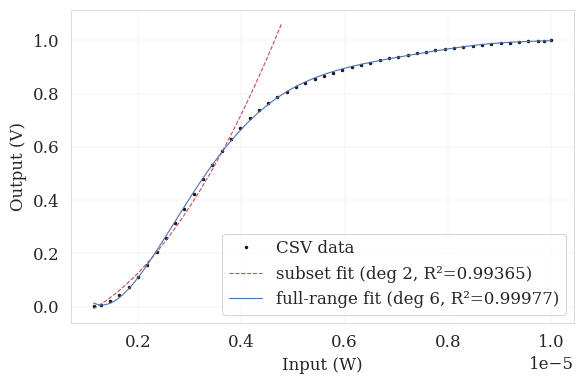

Saved figure to pd_tia_two_fits.pdf


In [13]:
# ------- CONFIGURATION -------
CSV_PATH = "component_data/pd_tia_sim_data.csv"
SUBSET_X_MAX = 4e-6  # “first-third” in the earlier example
OUT_FNAME = "pd_tia_two_fits.pdf"
# ------------------------------

# 1) Load and discard the first four low-level entries
df_full = pd.read_csv(CSV_PATH).iloc[4:].reset_index(drop=True)

# 2) Identify the “subset” region (x < SUBSET_X_MAX)
df_subset = df_full[df_full["input"] < SUBSET_X_MAX].copy()

# 3) — Quadratic fit on the subset (y = a·x² + b) —
x2_sub = df_subset["input"].values ** 2
y_sub = df_subset["output"].values
a_sub, b_sub = np.polyfit(x2_sub, y_sub, deg=1)
y_fit_sub = a_sub * df_subset["input"].values ** 2 + b_sub
r2_sub = r2_score(y_sub, y_fit_sub)

# 4) — n-th-order fit on the full valid range —
degree_full = 6  # get_ideal_degree(CSV_PATH)          # chooses degree automatically
coeff_full = np.polyfit(df_full["input"], df_full["output"], degree_full)
y_fit_full = np.polyval(coeff_full, df_full["input"].values)
r2_full = r2_score(df_full["output"].values, y_fit_full)

# 5) Plot everything together
plt.figure(figsize=(6, 4))

# Raw data
plt.plot(df_full["input"], df_full["output"], "k.", label="CSV data")

# Subset quadratic fit
forecast_len = 1.2  # 20% forecast
x_plot_sub = np.linspace(
    df_subset["input"].min(), forecast_len * df_subset["input"].max(), 200
)
plt.plot(
    x_plot_sub,
    a_sub * x_plot_sub**2 + b_sub,
    "r--",
    label=f"subset fit (deg 2, R²={r2_sub:.5f})",
)

# Full-range fit
x_plot_full = np.linspace(df_full["input"].min(), df_full["input"].max(), 400)
plt.plot(
    x_plot_full,
    np.polyval(coeff_full, x_plot_full),
    "b-",
    label=f"full-range fit (deg {degree_full}, R²={r2_full:.5f})",
)

plt.xlabel("Input (W)")
plt.ylabel("Output (V)")
# plt.title("PD-TIA Distortion Saturation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_FNAME)
plt.show()
plt.close()

print(f"Saved figure to {OUT_FNAME}")